
### Generating and Plotting Betatron Oscillations

The goal of this code is to simulate the Betatron oscillations described by an electron circulating in Sirius, as a function of the *azimuth coordinate* $s$, for multiple turns.

More specifically, we will strive to reproduce Figure 2.6 of the *Sands textbook*, representing not only the electron trajectories, but also the 'betatron function' $\beta(s)$ and the envelope $X(s) = a\sqrt{(\beta(s))}$

Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pymodels
import pyaccel

#### Model creation

In [16]:
model_sirius = pymodels.si.create_accelerator()

model_booster = pymodels.bo.create_accelerator()

In [17]:
model = model_sirius[:] # Make a copy of the chosen model

model.cavity_on = False
model.radiation_on = False
model.vchamber_on = True

In [18]:
print(model)

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : True
lattice version: SI_V25_04_1.21.3
lattice size   : 6752
lattice length : 518.3898999999917 m


#### Some infos/calculations about Sirius

Total current:

\begin{equation}
    I_{total} = 200\, mA = 1.25\cdot10^{18}\, electrons/s
\end{equation}

Current per bunch (constant fill):

\begin{equation}
    I_{bunch} = 0.232\, mA = 1.45\cdot 10^{15}\, electrons/s
\end{equation}

Number of bunches (considering constant fill, i.e., $\#_{bunches} = \#_{buckets}$):

\begin{equation}
    \#_{bunches} = \frac{200}{0.232} \approx 864\: bunches
\end{equation}

Time per turn:

\begin{equation}
    t_{turn} = \frac{518.4\, m}{299792458\, m/s} \approx 1.729\cdot10^{-6}\, s
\end{equation}

electrons per bunch (*constant fill*):

$$I_{bunch}[e's/s] = \frac{\#_{electrons / bunch}}{t_{turn}[s]}$$

\begin{equation}
    \implies \#_{electrons / bunch} = I_{bunch}[e's/s]\cdot t_{turn}[s] \approx 2.5\cdot 10⁹\, electrons/bunch
\end{equation}


In [19]:
print(f"{200*1e-3/(1.6*1e-19):.2e} electrons/s")
print(f"{0.232*1e-3/(1.6*1e-19):.2e} electrons/bunch/s")
print(f"{200/0.232:.3f} bunches")
print(f"{518.4/299792458:.3e} seconds per turn")
print(f"{1.45*1e15*1.729*1e-6:.3e} electrons/bunch")

1.25e+18 electrons/s
1.45e+15 electrons/bunch/s
862.069 bunches
1.729e-06 seconds per turn
2.507e+09 electrons/bunch


#### Extracting parameters

Twiss

In [20]:
twiss, *_ = pyaccel.optics.calc_twiss(model)

print('Twiss array:\n')
print('type:', type(twiss), '\nshape:', np.shape(twiss), '\n') # TwissArray w/ < lattice_size > elements
print('1st element:\n\n', twiss[0], '\n', sep='')
print(type(twiss[0]))

Twiss array:

type: <class 'pyaccel.optics.twiss.TwissArray'> 
shape: (6752,) 

1st element:

spos          : +0.000e+00
rx, ry        : +0.000e+00, +0.000e+00
px, py        : +0.000e+00, +0.000e+00
de, dl        : +0.000e+00, +0.000e+00
mux, muy      : +0.000e+00, +0.000e+00
betax, betay  : +1.720e+01, +3.604e+00
alphax, alphay: -1.789e-13, +4.519e-14
etax, etapx   : +4.927e-08, +7.077e-16
etay, etapy   : +0.000e+00, +0.000e+00

<class 'pyaccel.optics.twiss.Twiss'>


spos; beta_x; beta_y

In [21]:
spos = twiss.spos
beta_x = twiss.betax
beta_y = twiss.betay

print(np.shape(spos), np.shape(beta_x), np.shape(beta_y))

(6752,) (6752,) (6752,)


In [22]:
idx = range(0, 120, 10)
print('spos:\n', spos[idx], '\n\nbeta_x:\n', beta_x[idx], '\n\nbeta_y:\n', beta_y[idx])

spos:
 [0.        2.5748475 4.2347475 5.0167475 5.4467475 5.5187475 5.8906075
 6.5407475 8.0707475 8.5312475 8.9562475 9.1762475] 

beta_x:
 [17.2013798  17.58680467 13.88877507  2.52811873  0.47558268  0.33921808
  0.43558214  3.84448009  7.66961024  3.07504414  0.89977833  0.44039862] 

beta_y:
 [ 3.60430347  5.44372673 10.93008619 24.94426761 28.90042684 28.81518193
 24.91188462 14.04268058 11.60488289 20.04729413 26.73779782 27.59604807]


#### Tracking trajectories

In [23]:
# Particle 1:
x1_0 = 0
px1_0 = 1e-7
y1_0 = 0
py1_0 = 1e-7

# Particle 2:
x2_0 = 2e-6
px2_0 = 0
y2_0 = 1e-6
py2_0 = 0

coord_inits = np.transpose(np.array([[x1_0, px1_0, y1_0, py1_0, 0, 0], [x2_0, px2_0, y2_0, py2_0, 0, 0]]))
print('Initial coordinates:\n\n', coord_inits, 'm', '\n\nshape:', np.shape(coord_inits))

Initial coordinates:

 [[0.e+00 2.e-06]
 [1.e-07 0.e+00]
 [0.e+00 1.e-06]
 [1.e-07 0.e+00]
 [0.e+00 0.e+00]
 [0.e+00 0.e+00]] m 

shape: (6, 2)


In [24]:
coord_fins, *_ = pyaccel.tracking.line_pass(model, coord_inits, indices='open') 

print(np.shape(coord_fins))
# -> (6, 2, 6752) -> (6, n_particles, n_elements)

print('\nIntermediate coordinates:\n')
print('Particle 1:', coord_fins[:, 0, int(coord_fins.shape[2]/2)], 'm')
print('Particle 2:', coord_fins[:, 1, int(coord_fins.shape[2]/2)], 'm')

print('\nFinal coordinates:\n')
print('Particle 1:', coord_fins[:, 0, -1], 'm\nParticle 2:', coord_fins[:, 1, -1], 'm')

(6, 2, 6752)

Intermediate coordinates:

Particle 1: [-1.14944814e-06 -3.23422046e-07  5.39173096e-07  1.40821845e-07
  0.00000000e+00 -5.91070855e-13] m
Particle 2: [-2.02767790e-07  1.16944665e-07 -6.27194660e-08 -2.01866097e-07
  0.00000000e+00 -1.98132482e-12] m

Final coordinates:

Particle 1: [ 9.75462926e-07  8.23683418e-08  2.93942318e-07  5.78747470e-08
  0.00000000e+00 -3.42565915e-12] m
Particle 2: [ 1.64739185e-06 -6.59481731e-08  5.78685227e-07 -2.26326281e-07
  0.00000000e+00 -1.93755708e-12] m


#### Plots

##### Fig. (a)

In [25]:
# Getting original parameters
spos = twiss.spos
beta_x = twiss.betax
beta_y = twiss.betay

In [26]:
# Limiting to 1/5 of the ring for better visualization:
spos = spos[:int(len(spos)/5)]
beta_x = beta_x[:int(len(beta_x)/5)]
beta_y = beta_y[:int(len(beta_y)/5)]

Plotting betatron functions ($\beta_x$ and $\beta_y$) along the ring:

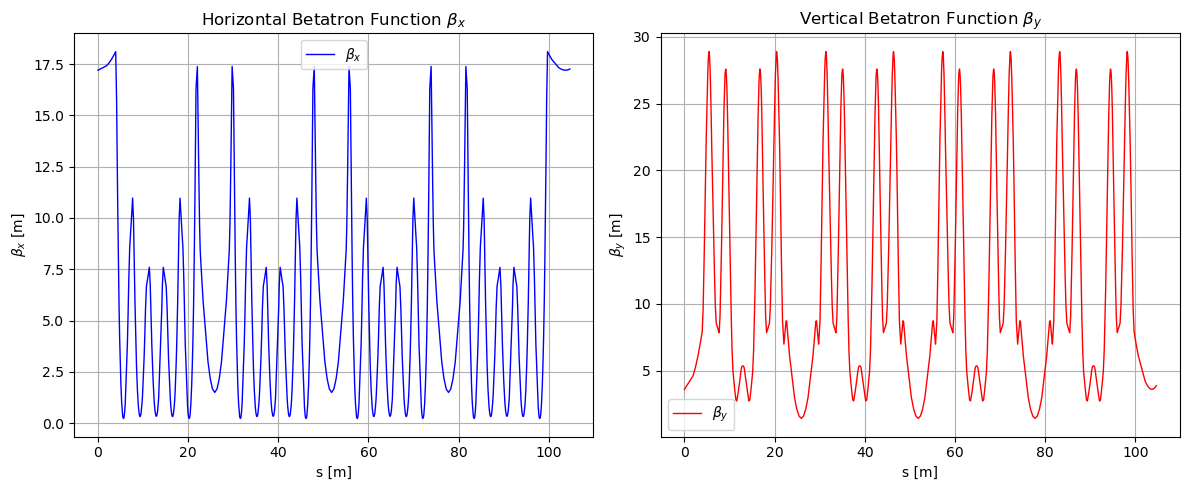

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(spos, beta_x, label=r'$\beta_x$', color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_x$ [m]')
plt.title(r'Horizontal Betatron Function $\beta_x$')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(spos, beta_y, label=r'$\beta_y$', color='red', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_y$ [m]')
plt.title(r'Vertical Betatron Function $\beta_y$')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

##### Fig. (b)

First, calculating the trajectories' envelopes $a\sqrt{\beta(s)}$:

To determine the constant $a$ (*which depends on the initial conditions of the particular trajectory*), we use:

\begin{equation}
    a^2 = \frac{x^2_1}{\beta_1} + \beta_1\left[x'_1 - \frac{\beta'_1}{2\beta_1}x_1\right]²,
\end{equation}

where $(x_1, x'_1, \beta_1, \beta'_1)$ $\triangleq$ $\left(x(s_1), x'(s_1), \beta(s_1), \beta'(s_1)\right)$, for a given $s_1$ where $(x,$ $x')$ are known.

Moreover, $\beta'(s)$ can be obtained as:

\begin{equation}
    \beta'(s) = -2\alpha(s),
\end{equation}
and thus:

\begin{equation}
    a = \left[\frac{x^2_1}{\beta_1} + \beta_1\left(x'_1 + \frac{\alpha_1}{\beta_1}x_1\right)²\right]^{\frac{1}{2}}.
\end{equation}

Particle 1

In [28]:
def calc_a(x1, xprime1, betax1, alphax1):
    return np.sqrt(x1**2/betax1 + betax1*(xprime1 + alphax1/betax1*x1)**2)

# x motion:
alpha_x = twiss.alphax

# constant 'a' using initial coordinates:
a_x1 = x1_0
a_xprime1 = px1_0
a_betax1 = beta_x[0] # beta at the start of the ring
a_alphax1 = alpha_x[0] # alpha at the start of the ring

# a = [x_1^2/\beta_1 + \beta_1*(x'_1 + (\alpha_1/\beta_1)*x_1 )^2]^(1/2):
a_x_par1 = calc_a(a_x1, a_xprime1, a_betax1, a_alphax1)

# envelope function (a\sqrt{\beta}):
envelope_x1 = a_x_par1 * np.sqrt(beta_x)

# ---  ---

# y motion:
alpha_y = twiss.alphay

# At the start of the ring:
a_y1 = y1_0
a_yp1 = py1_0
a_betay1 = beta_y[0]
a_alphay1 = alpha_y[0]
a_y_par1 = calc_a(a_y1, a_yp1, a_betay1, a_alphay1)

# envelope:
envelope_y1 = a_y_par1 * np.sqrt(beta_y)


Particle 2

In [29]:
# x motion:
a_x2 = x2_0
a_xprime2 = px2_0
a_betax2 = beta_x[0]
a_alphax2 = alpha_x[0]
a_x_par2 = calc_a(a_x2, a_xprime2, a_betax2, a_alphax2)
envelope_x2 = a_x_par2 * np.sqrt(beta_x)

# y motion:
a_y2 = y2_0
a_yp2 = py2_0
a_betay2 = beta_y[0]
a_alphay2 = alpha_y[0]
a_y_par2 = calc_a(a_y2, a_yp2, a_betay2, a_alphay2)
envelope_y2 = a_y_par2 * np.sqrt(beta_y)

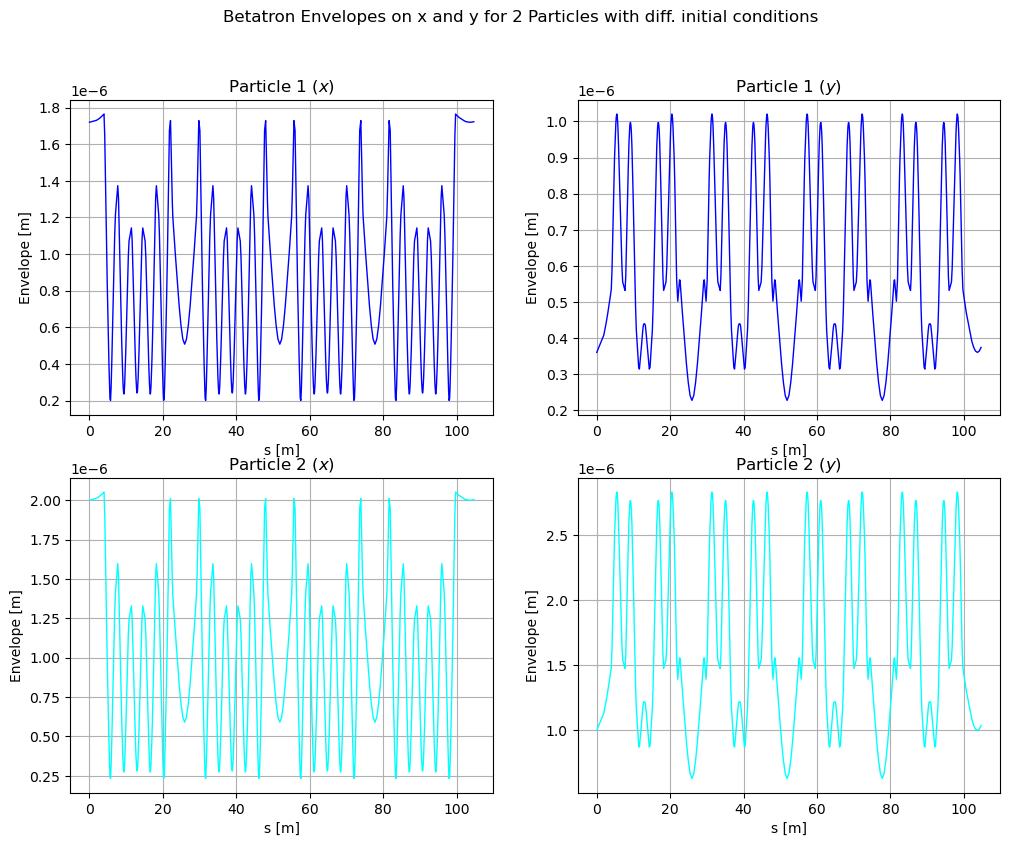

In [30]:
# plotting all envelopes:
plt.figure(figsize=(12, 9))

# particle 1:
plt.subplot(2, 2, 1) # x
plt.plot(spos, envelope_x1, color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 1 ($x$)')
plt.grid(True)

plt.subplot(2, 2, 2) # y
plt.plot(spos, envelope_y1, color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 1 ($y$)')
plt.grid(True)

# particle 2:
plt.subplot(2, 2, 3) # x
plt.plot(spos, envelope_x2, color='cyan', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 2 ($x$)')
plt.grid(True)

plt.subplot(2, 2, 4) # y
plt.plot(spos, envelope_y2, color='cyan', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('Envelope [m]')
plt.title('Particle 2 ($y$)')
plt.grid(True)

plt.suptitle('Betatron Envelopes on x and y for 2 Particles with diff. initial conditions')

plt.show()

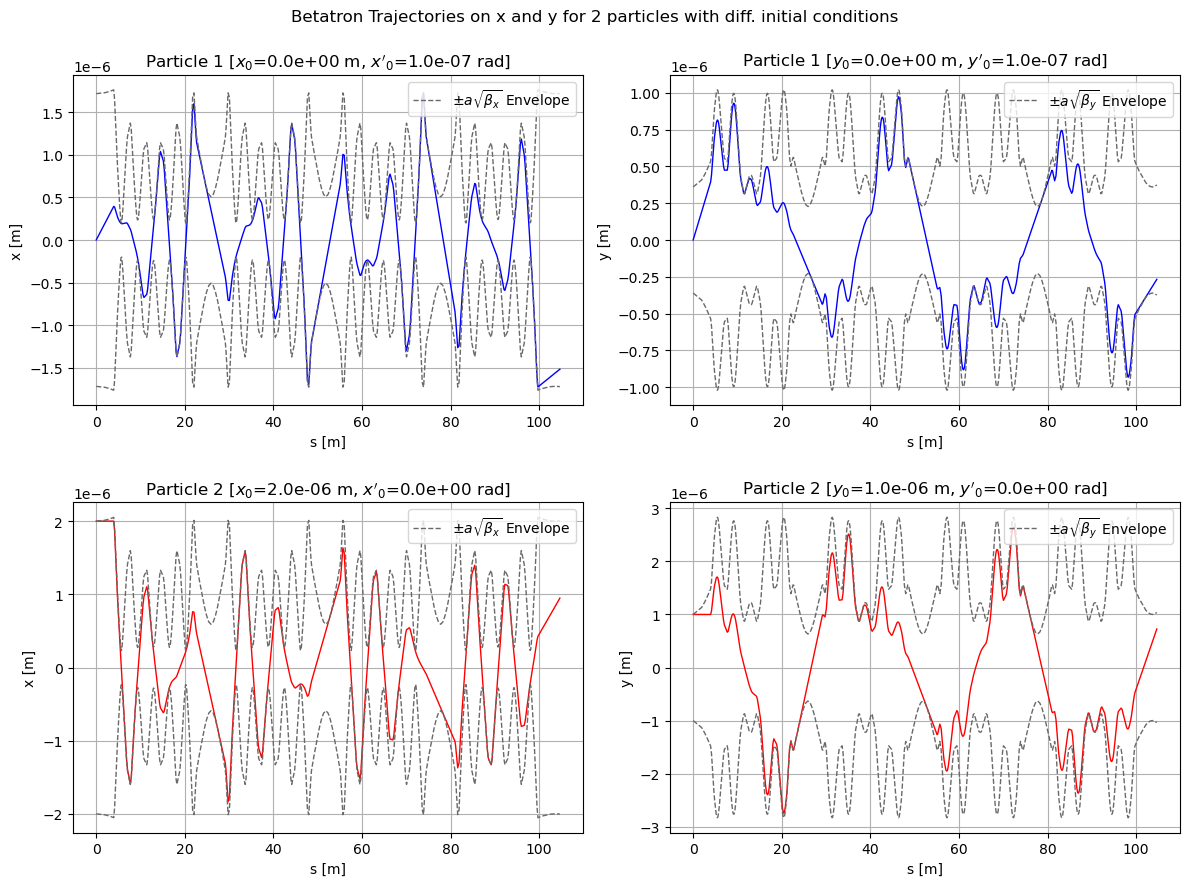

In [31]:
# plotting all trajectories:
plt.figure(figsize=(12, 9))

# Particle 1:
plt.subplot(2, 2, 1) # x
plt.plot(spos, coord_fins[0, 0, :len(spos)], color='blue', linewidth=1)
plt.plot(spos, envelope_x1, label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_x1, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title(f'Particle 1 [$x_0$={x1_0:.1e} m, $x\'_0$={px1_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(2, 2, 2) # y
plt.plot(spos, coord_fins[2, 0, :len(spos)], color='blue', linewidth=1)
plt.plot(spos, envelope_y1, label=r'$\pm a\sqrt{\beta_y}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_y1, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('y [m]')
plt.title(f'Particle 1 [$y_0$={y1_0:.1e} m, $y\'_0$={py1_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

# Particle 2:
plt.subplot(2, 2, 3) # x
plt.plot(spos, coord_fins[0, 1, :len(spos)], color='red', linewidth=1)
plt.plot(spos, envelope_x2, label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_x2, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title(f'Particle 2 [$x_0$={x2_0:.1e} m, $x\'_0$={px2_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(2, 2, 4) # y
plt.plot(spos, coord_fins[2, 1, :len(spos)], color='red', linewidth=1)
plt.plot(spos, envelope_y2, label=r'$\pm a\sqrt{\beta_y}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_y2, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel('y [m]')
plt.title(f'Particle 2 [$y_0$={y2_0:.1e} m, $y\'_0$={py2_0:.1e} rad]')
plt.grid(True)
plt.legend(loc='upper right')

plt.suptitle('Betatron Trajectories on x and y for 2 particles with diff. initial conditions')

plt.tight_layout()
plt.show()

Particle 1's trajectory on the horizontal and vertical planes (*with arrows*)

In [32]:
def add_arrows(ax, line, n_arrows=5):
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    
    step = len(xdata) // (n_arrows + 1)
    
    for i in range(step, len(xdata)-step, step):
        ax.annotate(
            '',
            xy=(xdata[i+1], ydata[i+1]),
            xytext=(xdata[i], ydata[i]),
            arrowprops=dict(
                arrowstyle='-|>',
                color=line.get_color(),
                lw=2.5
            ),
        )

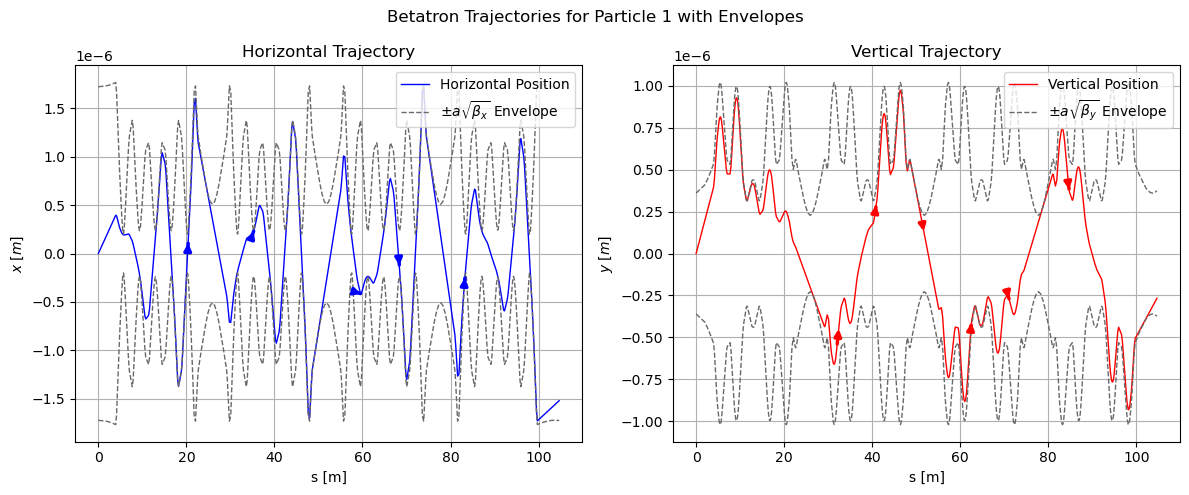

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- Horizontal --------
xaxis = axes[0]

line_h = xaxis.plot(
    spos,
    coord_fins[0, 0, :len(spos)],
    label='Horizontal Position',
    color='blue',
    linewidth=1
)[0]

add_arrows(xaxis, line_h, n_arrows=8)

xaxis.plot(spos, envelope_x1, '--', label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linewidth=1)
xaxis.plot(spos, -envelope_x1, '--', color='dimgrey', linewidth=1)

xaxis.set_xlabel('s [m]')
xaxis.set_ylabel(r'$x$ [$m$]')
xaxis.set_title('Horizontal Trajectory')
xaxis.grid(True)
xaxis.legend(loc='upper right')

# -------- Vertical --------
yaxis = axes[1]

line_v = yaxis.plot(
    spos,
    coord_fins[2, 0, :len(spos)],
    label='Vertical Position',
    color='red',
    linewidth=1
)[0]

add_arrows(yaxis, line_v, n_arrows=9)

yaxis.plot(spos, envelope_y1, '--', color='dimgrey', label=r'$\pm a\sqrt{\beta_y}$ Envelope', linewidth=1)
yaxis.plot(spos, -envelope_y1, '--', color='dimgrey', linewidth=1)

yaxis.set_xlabel('s [m]')
yaxis.set_ylabel(r'$y$ [$m$]')
yaxis.set_title('Vertical Trajectory')
yaxis.grid(True)
yaxis.legend(loc='upper right')

plt.suptitle('Betatron Trajectories for Particle 1 with Envelopes')

plt.tight_layout()
plt.show()

Same for particle 2

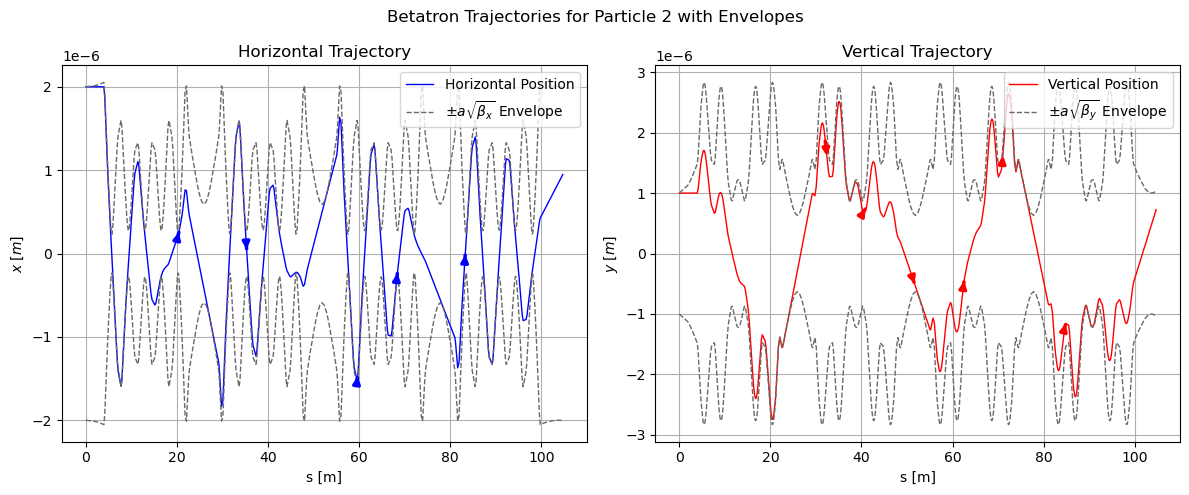

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- Horizontal --------
xaxis = axes[0]

line_h = xaxis.plot(
    spos,
    coord_fins[0, 1, :len(spos)],
    label='Horizontal Position',
    color='blue',
    linewidth=1
)[0]

add_arrows(xaxis, line_h, n_arrows=8)

xaxis.plot(spos, envelope_x2, '--', label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linewidth=1)
xaxis.plot(spos, -envelope_x2, '--', color='dimgrey', linewidth=1)
xaxis.set_xlabel('s [m]')
xaxis.set_ylabel(r'$x$ [$m$]')
xaxis.set_title('Horizontal Trajectory')
xaxis.grid(True)
xaxis.legend(loc='upper right')

# -------- Vertical --------
yaxis = axes[1]

line_v = yaxis.plot(
    spos,
    coord_fins[2, 1, :len(spos)],
    label='Vertical Position',
    color='red',
    linewidth=1
)[0]

add_arrows(yaxis, line_v, n_arrows=9)

yaxis.plot(spos, envelope_y2, '--', color='dimgrey', label=r'$\pm a\sqrt{\beta_y}$ Envelope', linewidth=1)
yaxis.plot(spos, -envelope_y2, '--', color='dimgrey', linewidth=1)
yaxis.set_xlabel('s [m]')
yaxis.set_ylabel(r'$y$ [$m$]')
yaxis.set_title('Vertical Trajectory')
yaxis.grid(True)
yaxis.legend(loc='upper right')

plt.suptitle('Betatron Trajectories for Particle 2 with Envelopes')

plt.tight_layout()
plt.show()

##### Fig. (d)

-> Tracking multiple turns

In [35]:

coord_ini0 = np.array([x1_0, px1_0, y1_0, py1_0, 0, 0])
coord_fin0, *_ = pyaccel.tracking.line_pass(model, coord_ini0, indices='closed') 

print(np.shape(coord_fin0))
# -> (6, 6752) -> (6, lattice_size+1)

coord_ini1 = coord_fin0[:, -1] # Getting the final coordinates after 1 turn
coord_fin1, *_ = pyaccel.tracking.line_pass(model, coord_ini1, indices='closed')

coord_ini2 = coord_fin1[:, -1] # Getting the final coordinates after 2 turns
coord_fin2, *_ = pyaccel.tracking.line_pass(model, coord_ini2, indices='closed')

coor_ini3 = coord_fin2[:, -1] # Getting the final coordinates after 3 turns
coord_fin3, *_ = pyaccel.tracking.line_pass(model, coor_ini3, indices='closed')

coor_ini4 = coord_fin3[:, -1] # Getting the final coordinates after 4 turns
coord_fin4, *_ = pyaccel.tracking.line_pass(model, coor_ini4, indices='closed')


(6, 6753)


Plotting tracjectories for multiple turns

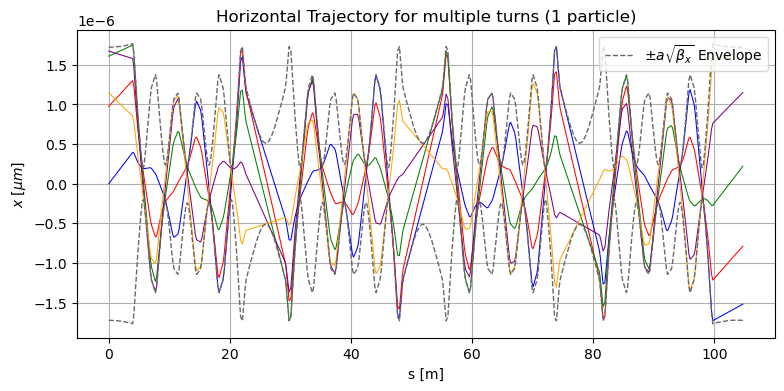

In [36]:
plt.figure(figsize=(9, 4))

plt.plot(spos, coord_fin0[0, :len(spos)], color='blue', linewidth=0.75)
plt.plot(spos, coord_fin1[0, :len(spos)], color='red', linewidth=0.75)
plt.plot(spos, coord_fin2[0, :len(spos)], color='green', linewidth=0.75)
plt.plot(spos, coord_fin3[0, :len(spos)], color='purple', linewidth=0.75)
plt.plot(spos, coord_fin4[0, :len(spos)], color='orange', linewidth=0.75)
# Adding envelopes sqrt(beta) to the plots for better visualization of the trajectories:
plt.plot(spos, envelope_x1, label=r'$\pm a\sqrt{\beta_x}$ Envelope', color='dimgrey', linestyle='--', linewidth=1)
plt.plot(spos, -envelope_x1, color='dimgrey', linestyle='--', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$x$ [$\mu m$]')
plt.title(r'Horizontal Trajectory for multiple turns (1 particle)')
plt.grid(True)
plt.legend(loc='upper right')

plt.show()

With arrows to indicate the trajectories

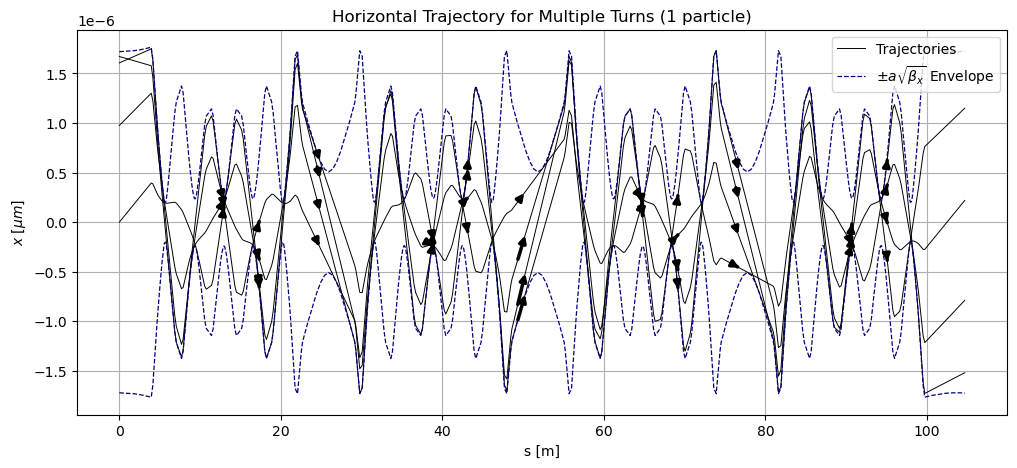

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))

lines = []
lines.append(ax.plot(spos, coord_fin0[0, :len(spos)], color='black', linewidth=0.7, label='Trajectories')[0])
lines.append(ax.plot(spos, coord_fin1[0, :len(spos)], color='black', linewidth=0.7)[0])
lines.append(ax.plot(spos, coord_fin2[0, :len(spos)], color='black', linewidth=0.7)[0])
lines.append(ax.plot(spos, coord_fin3[0, :len(spos)], color='black', linewidth=0.7)[0])

# Add arrows to each trajectory
for line in lines:
    add_arrows(ax, line, n_arrows=15)

# Envelopes
ax.plot(spos, envelope_x1, '--', color='navy', linewidth=0.9, label=r'$\pm a\sqrt{\beta_x}$ Envelope')
ax.plot(spos, -envelope_x1, '--', color='navy', linewidth=0.9)

ax.set_xlabel('s [m]')
ax.set_ylabel(r'$x$ [$\mu m$]')
ax.set_title('Horizontal Trajectory for Multiple Turns (1 particle)')
ax.grid(True)
plt.legend()

plt.show()

### Investigating the Tune ($\nu$) and Phase ($\phi(s)$) of the Betatron Oscillations

Base equations:

\begin{equation}
    \phi(s) = \int{\frac{ds}{\beta(s)}}
\end{equation}

\begin{equation}
    \left(\Delta\phi\right)_{1 turn} = \int_{s}^{s+L}{\frac{d\bar{s}}{\beta(\bar{s})}} = \oint{\frac{ds}{\beta(s)}} \triangleq 2\pi\nu,
\end{equation}
where $\int_{s}^{s+L}{\frac{d\bar{s}}{\beta(\bar{s})}}$ is the same for any $s$ due to the periodicity of $\beta$ $\,\left(\beta(s+L) = \beta(s)\right)$.

Then, for $j$ turns:

\begin{equation}
     \left(\Delta\phi\right)_{j turns} = j\cdot 2\pi\nu = \frac{t_j}{t_1}\cdot 2\pi\nu
\end{equation}

\begin{equation}
    \implies \left(\Delta\phi\right)_{j turns} = \nu \omega_r \cdot t_j,
\end{equation}
with $\omega_r \triangleq 2\pi/t_1$, and $t_1 = L/c$ the time taken to complete 1 full turn around the storage ring.

One can thus write the lateral displacement at any particular $s$ can be written as:


\begin{equation}
    x_s(t_j) = a\sqrt{\beta(s)}\cdot cos(\nu\omega_r \cdot t_j + \phi_{0s}),
\end{equation}
$\phi_{0s}$ being the phase at position $s$ in the first turn (turn 0).

Consequently, when measuring $x$ at a particular azimuth $s$ for multiple turns, since the amplitude value $a\sqrt{\beta(s)}$ is constant, one expects to observe a simple harmonic oscillation sampled at frequency $\nu\omega_r$

##### First of all, reproduce trajectories of Fig. (d) but dividing them by the envelope $X(s) = a\sqrt{\beta(s)}$


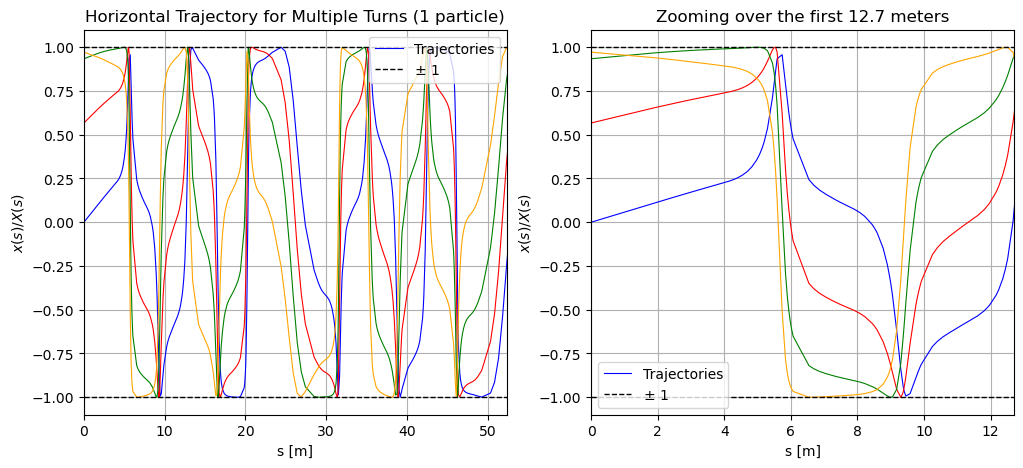

In [38]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(spos, coord_fin0[0, :len(spos)]/envelope_x1, color='blue', linewidth=0.8, label='Trajectories')
plt.plot(spos, coord_fin1[0, :len(spos)]/envelope_x1, color='red', linewidth=0.8)
plt.plot(spos, coord_fin2[0, :len(spos)]/envelope_x1, color='green', linewidth=0.8)
plt.plot(spos, coord_fin3[0, :len(spos)]/envelope_x1, color='orange', linewidth=0.8)
plt.hlines(1, 0, spos[-1], colors='black', linestyles='--', linewidth=1, label='$\pm$ 1')
plt.hlines(-1, 0, spos[-1], colors='black', linestyles='--', linewidth=1)

plt.xlabel('s [m]')
plt.ylabel(r'$x(s)/X(s)$')
plt.title('Horizontal Trajectory for Multiple Turns (1 particle)')
plt.legend(loc='upper right')
plt.xlim(0, spos[-1]/2)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(spos, coord_fin0[0, :len(spos)]/envelope_x1, color='blue', linewidth=0.8, label='Trajectories')
plt.plot(spos, coord_fin1[0, :len(spos)]/envelope_x1, color='red', linewidth=0.8)
plt.plot(spos, coord_fin2[0, :len(spos)]/envelope_x1, color='green', linewidth=0.8)
plt.plot(spos, coord_fin3[0, :len(spos)]/envelope_x1, color='orange', linewidth=0.8)
plt.hlines(1, 0, spos[-1], colors='black', linestyles='--', linewidth=1, label='$\pm$ 1')
plt.hlines(-1, 0, spos[-1], colors='black', linestyles='--', linewidth=1)

plt.xlabel('s [m]')
plt.ylabel(r'$x(s)/X(s)$')
plt.title('Zooming over the first 12.7 meters')
plt.legend()
plt.xlim(0, 12.7)
plt.grid(True)

plt.show()

#### Plot the phase $\phi(s)$ to better understand the above curves:

\begin{equation}
    \phi(s) = \int{\frac{ds}{\beta(s)}}
\end{equation}


First plotting $\beta_x$ and $1/\beta_x$ to visualize their behavior:

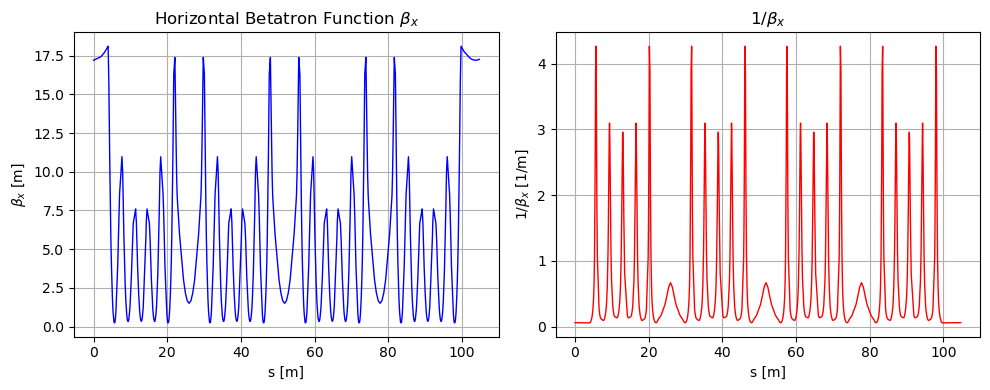

In [39]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(spos, beta_x, color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_x$ [m]')
plt.title(r'Horizontal Betatron Function $\beta_x$')
plt.grid(True) 

plt.subplot(1, 2, 2)
plt.plot(spos, 1/beta_x, color='red', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$1/\beta_x$ [1/m]')
plt.title(r'$1/\beta_x$')
plt.grid(True)

plt.tight_layout()
plt.show()

Determining $\phi(s)$ by numeric integration of $1/\beta(s)$ ~ *not precise due to the sharp peaks of*  $1/\beta(s)$

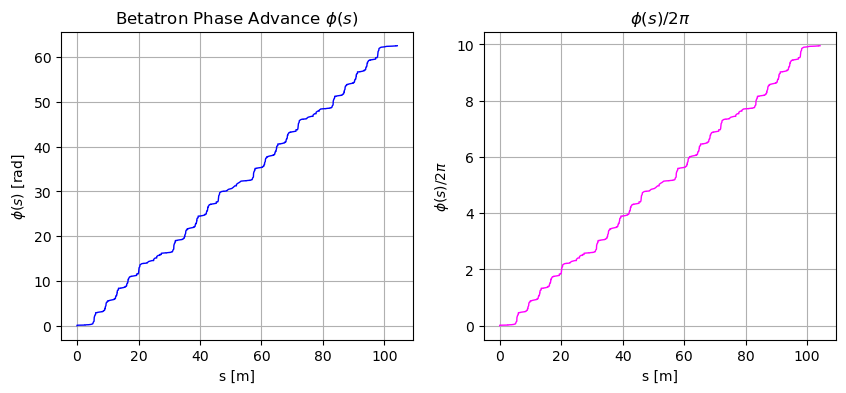

In [40]:
# Let's use cumulative trapezoidal integration

ds_array = np.diff(spos) # len = len(spos)-1 ~ difference between consecutive elements of spos

inv_beta_x = 1/beta_x

d_phi = (inv_beta_x[:-1] + inv_beta_x[1:]) * ds_array / 2 # Trapezoid rule

# Calculating the integral to get phi(s):

phi_s = np.cumsum(d_phi)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(spos[:-1], phi_s, color='blue', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$\phi(s)$ [rad]')
plt.title(r'Betatron Phase Advance $\phi(s)$')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(spos[:-1], phi_s/(2*np.pi), color='magenta', linewidth=1)
plt.xlabel('s [m]')
plt.ylabel(r'$\phi(s)/2\pi$')
plt.title(r'$\phi(s)/2\pi$')
plt.grid(True)
plt.show()

Plotting $x(s)/X(s)$ and $\phi(s)$ for the first 2 full cosine turns ($\Delta\phi \approx 4\pi$)

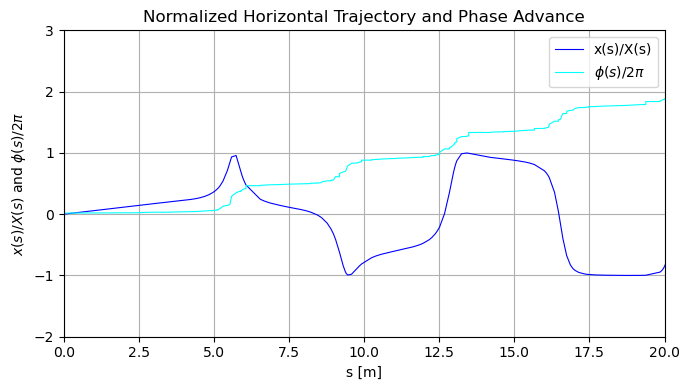

In [41]:
plt.figure(figsize=(7, 4))
plt.plot(spos[:-1], coord_fin0[0, :len(spos)-1]/envelope_x1[:-1], color='blue', linewidth=0.8, label='x(s)/X(s)')
plt.plot(spos[:-1], phi_s/(2*np.pi), color='cyan', linewidth=0.8, label=r'$\phi(s)/2\pi$')
plt.xlabel('s [m]')
plt.ylabel(r'$x(s)/X(s)$ and $\phi(s)/2\pi$')
plt.title('Normalized Horizontal Trajectory and Phase Advance')
plt.legend()
plt.xlim(0, 20)
plt.ylim(-2, 3)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Exploring the tune ($\nu$) and the betatron frequency ($\nu\omega_r$)

\begin{equation}
    \phi(s) = \int{\frac{ds}{\beta(s)}}
\end{equation}

\begin{equation}
    \nu = \frac{1}{2\pi}\left(\Delta\phi\right)_{1 turn} = \frac{1}{2\pi}\oint{\frac{ds}{\beta(s)}}
\end{equation}

Since $(\Delta\phi)_{1 turn}$ is the same for any starting $s$ (due to the periodicity of $\beta$), we can write simply:

\begin{equation}
    \nu = \frac{1}{2\pi}\int_0^L{\frac{ds}{\beta(s)}} = \frac{\phi(L)}{2\pi}
\end{equation}

Estimated horizontal tune (imprecise): nu_x = 49.670


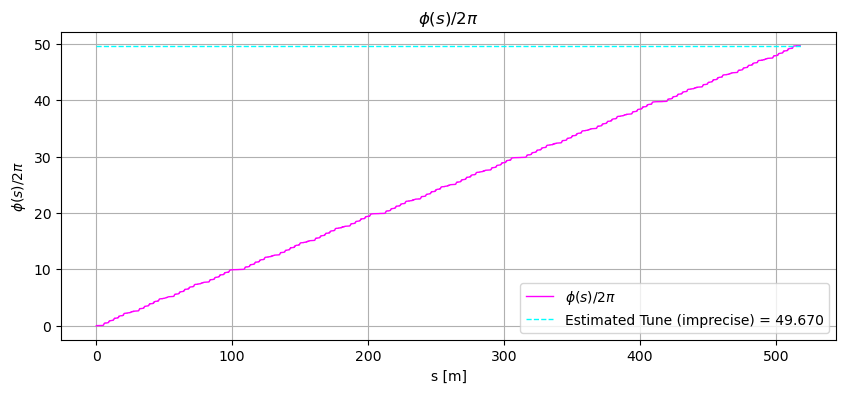

In [42]:
# Getting original parameters (full length)
spos = twiss.spos
beta_x = twiss.betax

# Calculating phi(s) for the full length of the ring:
ds_array = np.diff(spos) # len = len(spos)-1 
inv_beta_x = 1/beta_x
d_phi = (inv_beta_x[:-1] + inv_beta_x[1:]) * ds_array / 2 # Trapezoid rule
phi_s = np.cumsum(d_phi)

# Calculating the estimated tune from the total phase advance after one full turn:
tune_x = phi_s[-1]/(2*np.pi)
print(f'Estimated horizontal tune (imprecise): nu_x = {tune_x:.3f}')

# Plotting phi(s)/2pi for the full length of the ring and indicating the tune:
plt.figure(figsize=(10, 4))
plt.plot(spos[:-1], phi_s/(2*np.pi), color='magenta', linewidth=1, label=r'$\phi(s)/2\pi$')
plt.hlines(tune_x, 0, spos[-1], colors='cyan', linestyles='--', linewidth=1, label=f'Estimated Tune (imprecise) = {tune_x:.3f}')
plt.xlabel('s [m]')
plt.ylabel(r'$\phi(s)/2\pi$')
plt.title(r'$\phi(s)/2\pi$')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

##### Real tune (using *pyaccel.optics*' methods)

In [43]:
tune_pyaccel = pyaccel.optics.get_frac_tunes(model, dim='4D')[0]
print(f'Horizontal tune from pyaccel (mod 1): nu_x = {tune_pyaccel:.3f}')

tune_twiss = twiss[-1].mux/(2*np.pi)
print(f'Full horizontal tune from Twiss: nu_x = {tune_twiss:.3f}')

print(f'Horizontal tune from Twiss (mod 1): nu_x = {tune_twiss % 1:.3f}')

Horizontal tune from pyaccel (mod 1): nu_x = 0.096
Full horizontal tune from Twiss: nu_x = 49.096
Horizontal tune from Twiss (mod 1): nu_x = 0.096


##### Looking at multiple turns (*1 electron*)

In [44]:
model = model_sirius[:] # Create a copy of the model to avoid modifying the original one

model.cavity_on = False
model.radiation_on = False
model.vchamber_on = True

We will compute the coordinates of 1 electron after each full turn on the ring

In [45]:
nturns = 300
coord_ini = np.array([0, 1e-7, 0, 1e-7, 0, 0]) # [x0, x'0, y0, y'0, z0, delta0]
coord_fin, *_ = pyaccel.tracking.ring_pass(model, coord_ini, nr_turns=nturns, turn_by_turn=True, parallel=True)

In [46]:
np.shape(coord_fin) # -> (6, 300) -> (6 coord's, n_turns + 1)

(6, 301)

\begin{equation}
    x_j = X(s)\cdot cos(2\pi\nu\cdot j + \varphi_0)
\end{equation}

In our case $\varphi_0 = -\pi/2$ at $s$=0, and thus:

\begin{equation}
    x_j(s=0) = X(0)\cdot sin(2\pi\nu\cdot j)
\end{equation}

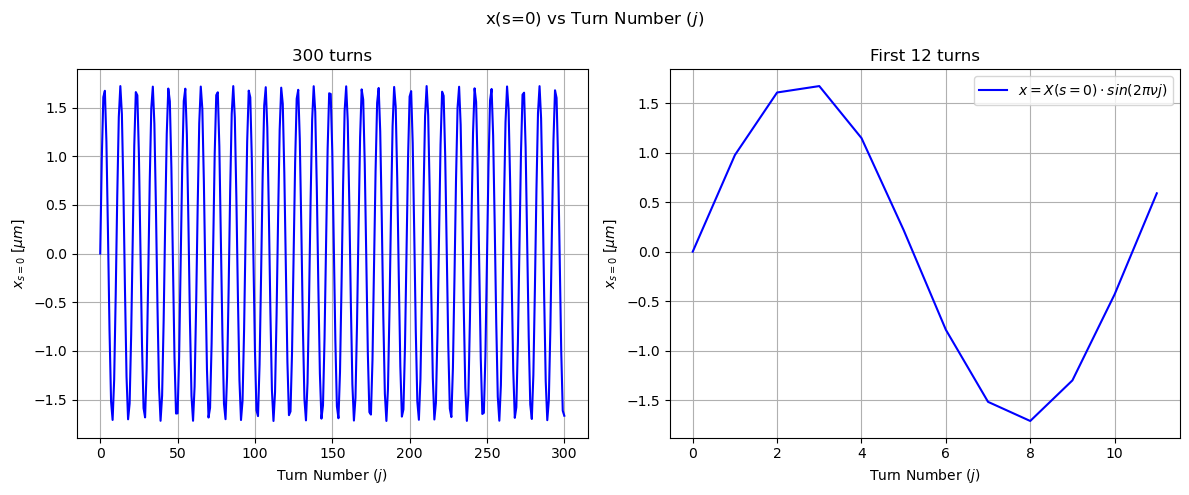

In [47]:
x_s = coord_fin[0, :]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(x_s)), x_s*1e6, color='blue')
plt.xlabel('Turn Number ($j$)')
plt.ylabel('$x_{s=0}$ [$\mu m$]')
plt.title('300 turns')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(12), x_s[:12]*1e6, color='blue', label=r'$x = X(s=0)\cdot sin(2\pi\nu j)$')
plt.xlabel('Turn Number ($j$)')
plt.ylabel('$x_{s=0}$ [$\mu m$]')
plt.title('First 12 turns')
plt.grid(True)
plt.legend()

plt.suptitle('x(s=0) vs Turn Number ($j$)')
plt.tight_layout()

plt.show() 

##### Studying the oscillation frequencies *for different tune values*

First, let's define two tune values - mod 1 - which are at the same distance $\Delta\nu$ (<0.5) from 0.5:

\begin{equation}
    \nu_1 = 0.5 - \Delta\nu
\end{equation}

\begin{equation}
    \nu_2 = 0.5 + \Delta\nu
\end{equation}

Then, notice that when writing the sine oscillation measured at a fixed $s$ (across multiple turn numbers j) for each tune:

\begin{equation}
    sin(2\pi\nu_1\cdot j) = sin(2\pi(0.5 - \Delta\nu)\cdot j) = sin(\pi\cdot j - 2\pi\Delta\nu\cdot j) =
\end{equation}

\begin{equation}
    sin(\pi\cdot j)cos(2\pi\Delta\nu\cdot j) - sin(2\pi\Delta\nu\cdot j)cos(\pi\cdot j) = -(-1)^j sin(2\pi\Delta\nu\cdot j),^*
\end{equation}
and

\begin{equation}
    sin(2\pi\nu_2\cdot j) = sin(\pi\cdot j + 2\pi\Delta\nu\cdot j) = +(-1)^j sin(2\pi\Delta\nu\cdot j).^*
\end{equation}


And thus:

\begin{equation}
    sin(2\pi\nu_2\cdot j) = - sin(2\pi\nu_1\cdot j),^*
\end{equation}

meaning that both tunes will result in a same measured oscillation frequency!$^*$

_*_ **This is valid only for integer $j$ !**

Let's see in practice what happens with the curves $x(s=0)$ vs $j$ for different tunes

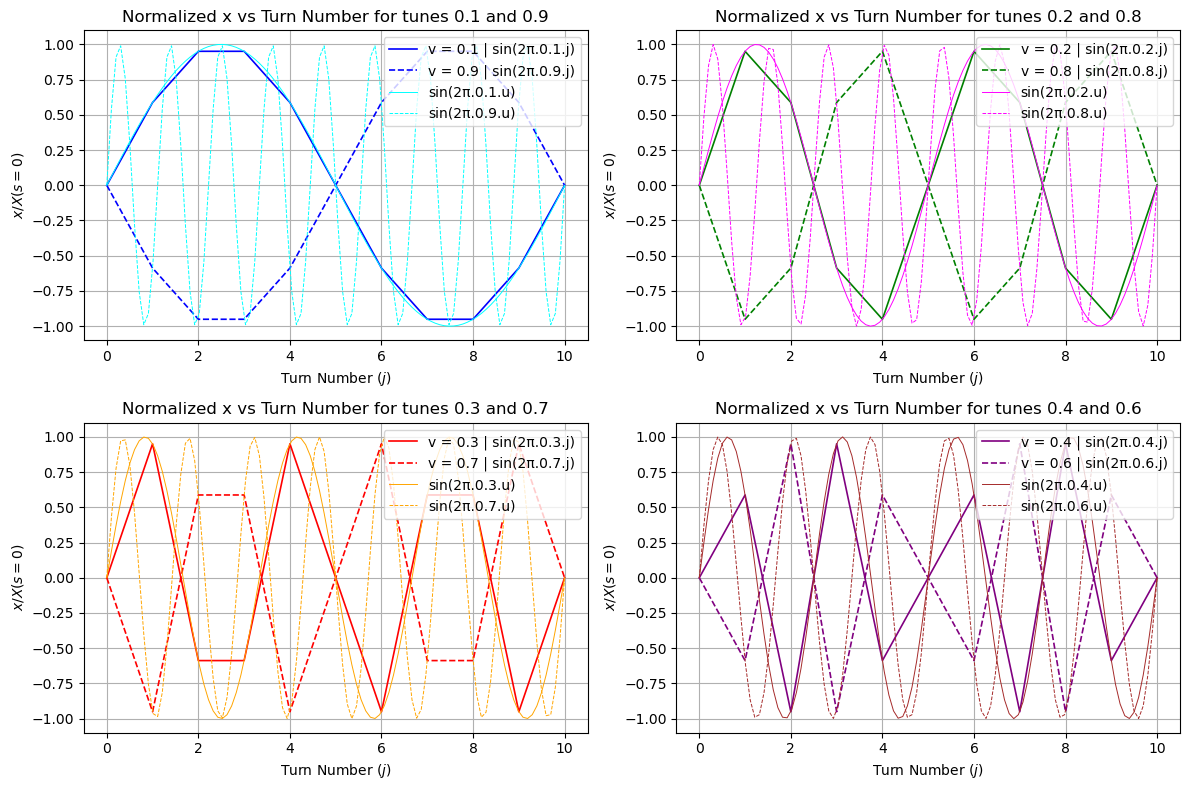

In [48]:
# Define tunes and number of turns
tunes_1 = [0.1, 0.2, 0.3, 0.4]
tunes_2 = [0.9, 0.8, 0.7, 0.6]
j = np.linspace(0, 10, 11)
j_highsample = np.linspace(0, 10, 100)

# Define colors for each subplot pair
colors = ['blue', 'green', 'red', 'purple', 'cyan', 'magenta', 'orange', 'brown']

# Create the figure with 4 subplots
plt.figure(figsize=(12, 8))

# Loop to create 4 subplots
for i, (tune_1, tune_2) in enumerate(zip(tunes_1, tunes_2)):
    plt.subplot(2, 2, i+1)
    norm_x_1 = np.sin(2 * np.pi * tune_1 * j)
    norm_x_2 = np.sin(2 * np.pi * tune_2 * j)
    norm_x_1_highsample = np.sin(2 * np.pi * tune_1 * j_highsample)
    norm_x_2_highsample = np.sin(2 * np.pi * tune_2 * j_highsample)
    
    # Plot each pair with different colors
    plt.plot(j, norm_x_1, color=colors[i], linewidth=1.2, label=f'v = {tune_1} | sin(2π.{tune_1:.1f}.j)')
    plt.plot(j, norm_x_2, color=colors[i], linestyle='--', linewidth=1.2, label=f'v = {tune_2} | sin(2π.{tune_2:.1f}.j)')

    plt.plot(j_highsample, norm_x_1_highsample, color=colors[i+4], linestyle='-', linewidth=0.7, label=f'sin(2π.{tune_1:.1f}.u)')
    plt.plot(j_highsample, norm_x_2_highsample, color=colors[i+4], linestyle='--', linewidth=0.7, label=f'sin(2π.{tune_2:.1f}.u)')

    # Add labels and titles
    plt.xlabel('Turn Number ($j$)')
    plt.ylabel(r'$x/X(s=0)$')
    plt.title(f'Normalized x vs Turn Number for tunes {tune_1} and {tune_2}')
    plt.grid(True)
    plt.legend(loc='upper right')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

See that the measured frequency will correspond always to that of the smallest $\nu$: $\nu_1 = 0.5 - \Delta$; since although $\nu_2 = 0.5 + \Delta$ implies a higher oscillation frequency, the sampling on integer steps $j$ makes the corresponding measured oscillations behave precisely as minus the first case's oscillations - meaning thus with the same frequency $\nu_1$ [Hz] ~ or equivalently $2\pi\nu_1$ [rads/s]

Checking the tunes that would be obtained through a Fourier analysis (DFT)

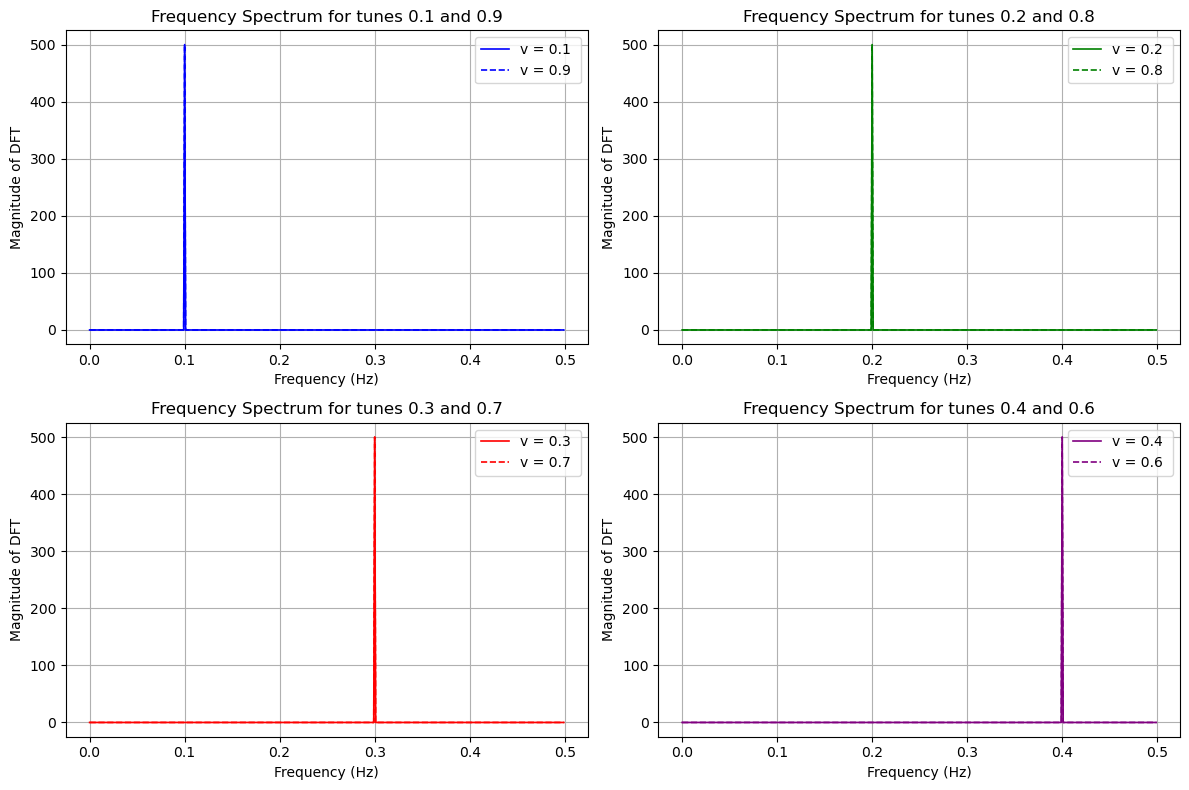

In [49]:
# Define tunes and number of turns
tunes_1 = [0.1, 0.2, 0.3, 0.4]
tunes_2 = [0.9, 0.8, 0.7, 0.6]
n_turns = 1000  # Increased number of turns for better frequency resolution

# Define colors for each subplot pair
colors = ['blue', 'green', 'red', 'purple']

# Create the figure with 4 subplots
plt.figure(figsize=(12, 8))

# Loop to create 4 subplots
for i, (tune_1, tune_2) in enumerate(zip(tunes_1, tunes_2)):
    plt.subplot(2, 2, i+1)
    
    # Generate the signals in the time domain (sinusoids)
    signal_1 = np.sin(2 * np.pi * tune_1 * np.arange(n_turns))
    signal_2 = np.sin(2 * np.pi * tune_2 * np.arange(n_turns))
    
    # Apply Discrete Fourier Transform (DFT) to move to the frequency domain
    dft_1 = np.fft.fft(signal_1)
    dft_2 = np.fft.fft(signal_2)
    
    # Compute the frequency bins corresponding to the DFT
    freqs = np.fft.fftfreq(n_turns)
    
    # Compute the magnitudes of the DFT components
    mag_dft_1 = np.abs(dft_1)
    mag_dft_2 = np.abs(dft_2)
    
    # Plot the DFT magnitudes (only for the positive frequencies)
    plt.plot(freqs[:n_turns//2], mag_dft_1[:n_turns//2], color=colors[i], linewidth=1.2, label=f'v = {tune_1} ')
    plt.plot(freqs[:n_turns//2], mag_dft_2[:n_turns//2], color=colors[i], linestyle='--', linewidth=1.2, label=f'v = {tune_2}')
    
    # Add labels and titles
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude of DFT')
    plt.title(f'Frequency Spectrum for tunes {tune_1} and {tune_2}')
    plt.grid(True)
    plt.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Thus confirming what we expected!

Plotting together with the sampled oscillation curves to get a final "bigger picture"

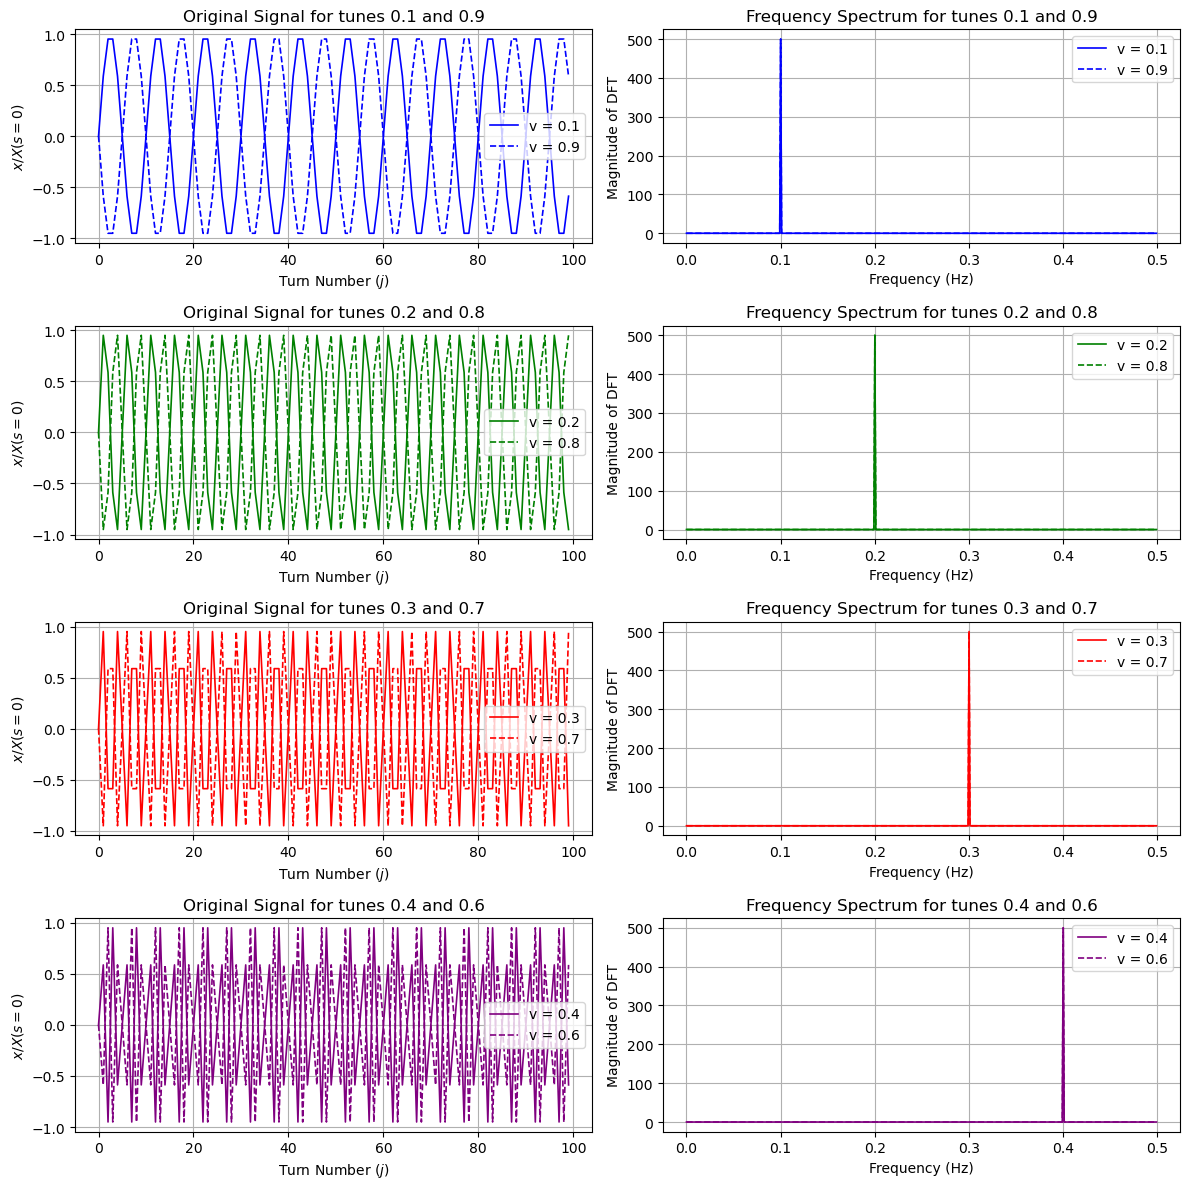

In [50]:
# Define tunes and number of turns
tunes_1 = [0.1, 0.2, 0.3, 0.4]
tunes_2 = [0.9, 0.8, 0.7, 0.6]
n_turns = 1000  # Increased number of turns for better frequency resolution

# Define colors for each subplot pair
colors = ['blue', 'green', 'red', 'purple']

# Create the figure with 4x2 subplots
plt.figure(figsize=(12, 12))

# Loop to create 4 rows of subplots
for i, (tune_1, tune_2) in enumerate(zip(tunes_1, tunes_2)):
    # Plot time-domain signal (first column)
    plt.subplot(4, 2, 2*i+1)
    signal_1 = np.sin(2 * np.pi * tune_1 * np.arange(n_turns))
    signal_2 = np.sin(2 * np.pi * tune_2 * np.arange(n_turns))
    
    # Plot only 1/10 of the total turns for better visualization
    plt.plot(range(n_turns // 10), signal_1[:n_turns // 10], color=colors[i], linewidth=1.2, label=f'v = {tune_1}')
    plt.plot(range(n_turns // 10), signal_2[:n_turns // 10], color=colors[i], linestyle='--', linewidth=1.2, label=f'v = {tune_2}')
    
    # Add labels and title for time-domain signal
    plt.xlabel('Turn Number ($j$)')
    plt.ylabel(r'$x/X(s=0)$')
    plt.title(f'Original Signal for tunes {tune_1} and {tune_2}')
    plt.grid(True)
    plt.legend()

    # Plot DFT (second column)
    plt.subplot(4, 2, 2*i+2)
    
    # Apply Discrete Fourier Transform (DFT) to move to the frequency domain
    dft_1 = np.fft.fft(signal_1)
    dft_2 = np.fft.fft(signal_2)
    
    # Compute the frequency bins corresponding to the DFT
    freqs = np.fft.fftfreq(n_turns)
    
    # Compute the magnitudes of the DFT components
    mag_dft_1 = np.abs(dft_1)
    mag_dft_2 = np.abs(dft_2)
    
    # Plot the DFT magnitudes (only for the positive frequencies)
    plt.plot(freqs[:n_turns//2], mag_dft_1[:n_turns//2], color=colors[i], linewidth=1.2, label=f'v = {tune_1}')
    plt.plot(freqs[:n_turns//2], mag_dft_2[:n_turns//2], color=colors[i], linestyle='--', linewidth=1.2, label=f'v = {tune_2}')
    
    # Add labels and title for DFT plot
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude of DFT')
    plt.title(f'Frequency Spectrum for tunes {tune_1} and {tune_2}')
    plt.grid(True)
    plt.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

##### Passing to the time domain

Now going from *num_turns* ($j$) to time ($t_j\,$~ *time to complete $j$ full turns*):

\begin{equation}
    x_s(t_j) = a\sqrt{\beta(s)}\cdot sin(2\pi\nu\cdot j) = a\sqrt{\beta(s)}\cdot sin(2\pi\nu\cdot \frac{t_j}{t_i})
\end{equation}

\begin{equation}
    \implies x_s(t_j) = a\sqrt{\beta(s)}\cdot sin(\nu\omega_r \cdot t_j),
\end{equation}
with:

\begin{equation}
    \omega_r \triangleq \frac{2\pi}{t_1}
\end{equation}

Time for 1 turn (t_1): 0.00000173 s = 1.73 µs


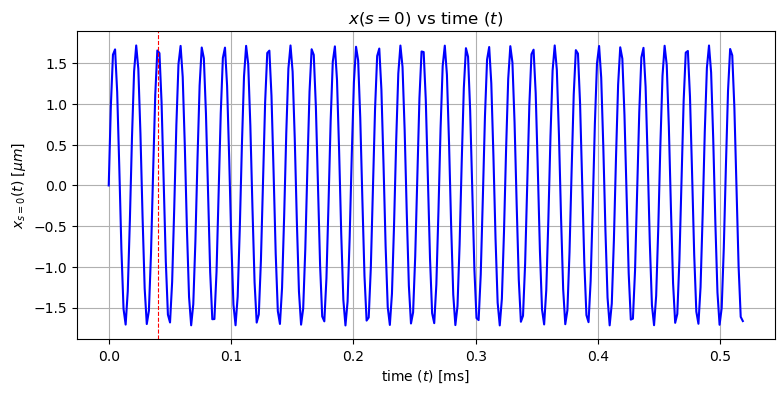

In [56]:
t_1 = model.length/(3*1e8) # Time for 1 turn (L/c) [s]

t_j = np.arange(len(x_s)) * t_1

print(f'Time for 1 turn (t_1): {t_1:.8f} s = {t_1*1e6:.2f} µs')

plt.figure(figsize=(9, 4))
plt.plot(t_j*1e3, x_s*1e6, color='blue')
plt.axvline(x=0.04, color='red', linewidth=0.8, linestyle='--')
plt.xlabel('time ($t$) [ms]')
plt.ylabel('$x_{s=0}(t)$ [$\mu m$]')
plt.title('$x(s=0)$ vs time ($t$)')
plt.grid(True)
plt.show()


Zooming in at the beginning

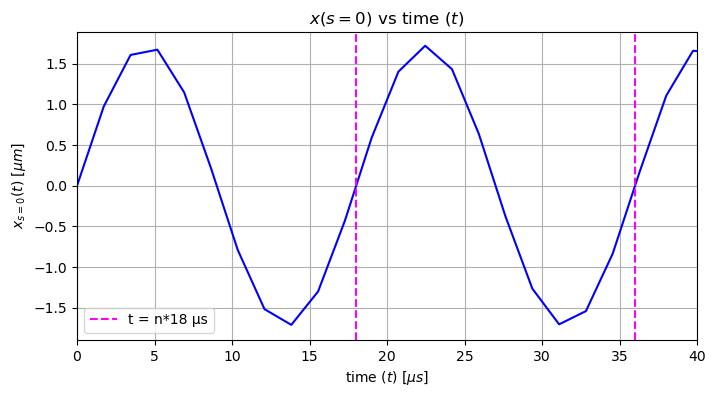

In [81]:
plt.figure(figsize=(8, 4))
plt.plot(t_j*1e6, x_s*1e6, color='blue')
plt.axvline(x=18, color='magenta', linestyle='--', label='t = n*18 µs')
plt.axvline(x=2*18, color='magenta', linestyle='--')
plt.xlabel('time ($t$) [$\mu s$]')
plt.ylabel('$x_{s=0}(t)$ [$\mu m$]')
plt.title('$x(s=0)$ vs time ($t$)')
plt.grid(True)
plt.xlim(0, 40)
plt.legend()
plt.show()

##### Finding the betatron frequency ($\nu\omega_r$):

From the previous graph, we see that $\nu\omega_r\cdot t_{betatron} = 2\pi$ for $t_{betatron} \approx 18 \mu s$

$\implies \nu\omega_r \approx \frac{2\pi}{18\cdot10^{-6}} rads/s$

In [82]:
freq_betatron = 2*np.pi/(18*1e-6) # rads/s

print(f'Betatron frequency: {freq_betatron:.2e} rad/s = {freq_betatron/(2*np.pi):.2f} Hz')

Betatron frequency: 3.49e+05 rad/s = 55555.56 Hz


Thus  $\nu\omega_r \approx 350.000$  rads/s